# Hidden Gems Analysis (Bonus)

## Business Problem

Sephora's catalog has thousands of products, but visibility doesn't always track quality. Some well-reviewed, well-loved products stay buried under low review counts or low `loves_count`, simply because they haven't been discovered yet — while other products get outsized attention that their ratings don't fully justify. Neither of these is visible from Sephora's own category or bestseller labels.

This connects directly to **Notebook 03 (Product Clustering)**, where the product-level K-Means segmentation surfaced a cluster we named **"Budget Gems"**: products with the lowest average price and the highest average rating, but without the review volume or engagement of the "Popular Favorites" cluster. That clustering result was descriptive — it told us *that* an underrated segment exists. This notebook picks up where it left off and asks a sharper, product-level question: *which individual products* are the strongest hidden gems, and can we rank them?

## Objective

Instead of training a predictive model, this notebook takes a business-analytics approach: engineer a custom **Hidden Gem Score** that combines signals such as product rating, recommendation rate, review helpfulness, and review/loves volume, then use it to rank and surface products that appear to be undervalued relative to their quality.

## Business Question

Which products deserve greater visibility despite receiving relatively little attention — and, conversely, which highly-visible products may be overrated relative to how customers actually rate them?

## Possible Outputs

- Hidden Gems — high rating, low visibility (the product-level counterpart to the "Budget Gems" cluster from Notebook 03)
- Most Overrated Products — high visibility, comparatively weaker satisfaction
- Best Value Products — strong rating relative to price
- Best Affordable Products
- Premium Products Worth Their Price — cross-check against the "Luxury Favorites" and "Premium Niche" segments from Notebook 03

## Data

- `cleaned_product_info.csv` — rating, price_usd, loves_count, reviews, category fields
- `cleaned_reviews.csv` — rating, helpfulness, total_pos_feedback_count (recommendation/helpfulness signals not available at the product level in `cleaned_product_info.csv`, so these will need to be aggregated per `product_id`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
products = pd.read_csv("data/processed/cleaned_product_info.csv")
reviews = pd.read_csv("data/processed/cleaned_reviews.csv")

print("products:", products.shape)
print("reviews:", reviews.shape)

products: (7305, 20)
reviews: (1503850, 15)


### Data Cleaning & Preprocessing
Core fields needed: price_usd, rating, reviews, loves_count. These were cleaned in Notebook 01, but double-check for missing values before scoring.

In [3]:
score_feats = ["price_usd", "rating", "reviews", "loves_count"]
print(products[score_feats].isna().sum())

products_clean = products.dropna(subset=score_feats).copy()
print(f"Products available for scoring: {len(products_clean)} (out of {len(products)})")

price_usd      0
rating         0
reviews        0
loves_count    0
dtype: int64
Products available for scoring: 7305 (out of 7305)


### Feature Engineering

#### Quality Score — Bayesian-adjusted rating

Using the raw `rating` directly is misleading: a product with a single 5.0-star review looks identical to one with 5.0 stars across 2,000 reviews. To fix this, ratings are shrunk toward the catalog-wide mean, with the amount of shrinkage controlled by how many reviews the product has (the classic "weighted rating" formula, same idea IMDb uses for its Top 250):

$$\text{adjusted\_rating} = \frac{v}{v+m} \cdot R + \frac{m}{v+m} \cdot C$$

where:<br>
- `R` is the product's own rating,
- `v` is its review count,
- `C` is the catalog mean rating,
- `m` is a prior review-count threshold (here the median review count).<br>
A product with very few reviews gets pulled toward the catalog average; a product with many reviews keeps close to its own rating.

#### Visibility Score

`reviews` and `loves_count` are both strongly right-skewed (same finding as Notebook 03), so `log1p` is applied before combining them into a single standardized visibility signal.

In [4]:
C = products_clean["rating"].mean()
m = products_clean["reviews"].median()
v = products_clean["reviews"]
R = products_clean["rating"]

products_clean["adjusted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C

print(f"Catalog mean rating (C): {C:.3f}")
print(f"Shrinkage prior (m, median review count): {m:.0f}")
products_clean[["product_name", "rating", "reviews", "adjusted_rating"]].sort_values("reviews").head()

Catalog mean rating (C): 4.209
Shrinkage prior (m, median review count): 136


,product_name,rating,reviews,adjusted_rating
1426,Paper+ Bold Travel Spray,4.0,1.0,4.207536
6119,Mini Brazilian Joia Strengthening + Smoothing Conditioner,5.0,1.0,4.214836
439,High Roller Crease Brush & Cooling Roller,5.0,1.0,4.214836
6916,Voce Viva Perfume Set,5.0,1.0,4.214836
6919,Go-Clutch Finishing Powder Refill Pan,4.0,1.0,4.207536


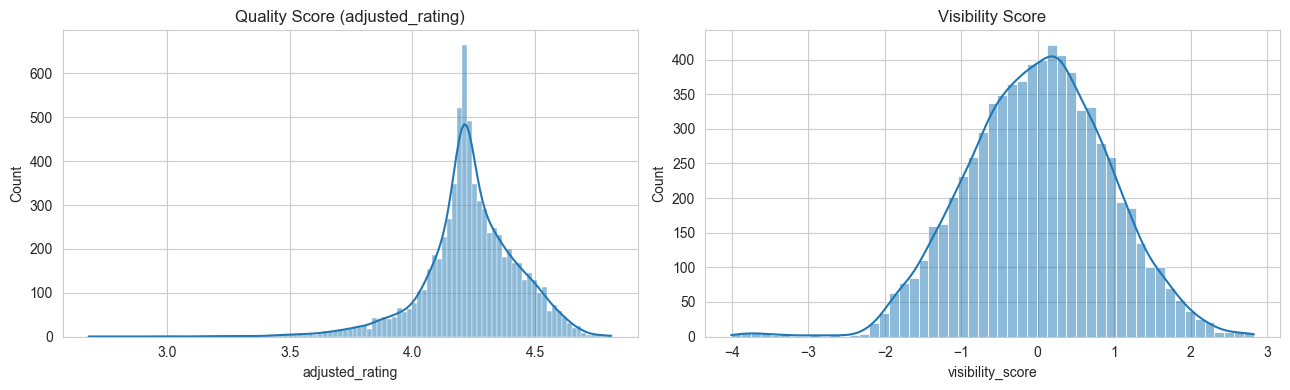

In [5]:
products_clean["log_reviews"] = np.log1p(products_clean["reviews"])
products_clean["log_loves"] = np.log1p(products_clean["loves_count"])
products_clean["log_price"] = np.log1p(products_clean["price_usd"])

visibility_scaler = StandardScaler()
visibility_z = visibility_scaler.fit_transform(products_clean[["log_reviews", "log_loves"]])
products_clean["visibility_score"] = visibility_z.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(products_clean["adjusted_rating"], kde=True, ax=axes[0])
axes[0].set_title("Quality Score (adjusted_rating)")
sns.histplot(products_clean["visibility_score"], kde=True, ax=axes[1])
axes[1].set_title("Visibility Score")
plt.tight_layout()
plt.show()

### Segmentation & Product Popularity
Just like in notebook 03, products with less than 5 reviews are excluded - noise prevention. Additionally popularity categories are established based on new columns: quality percentage and visibility percentage.

In [6]:
eligible = products_clean[products_clean["reviews"] >= 5].copy()

eligible["quality_pct"] = eligible["adjusted_rating"].rank(pct=True)
eligible["visibility_pct"] = eligible["visibility_score"].rank(pct=True)

def classify(row):
    hi, lo = 0.70, 0.30
    if row["quality_pct"] >= hi and row["visibility_pct"] <= lo:
        return "Hidden Gem"
    if row["quality_pct"] <= lo and row["visibility_pct"] >= hi:
        return "Overrated"
    if row["quality_pct"] >= hi and row["visibility_pct"] >= hi:
        return "Popular Favorite"
    if row["quality_pct"] <= lo and row["visibility_pct"] <= lo:
        return "Underperformer"
    return "Mainstream / Average"

eligible["gem_segment"] = eligible.apply(classify, axis=1)
eligible["gem_segment"].value_counts()

gem_segment
Mainstream / Average    4531
Popular Favorite         915
Overrated                664
Underperformer           548
Hidden Gem               239
Name: count, dtype: int64

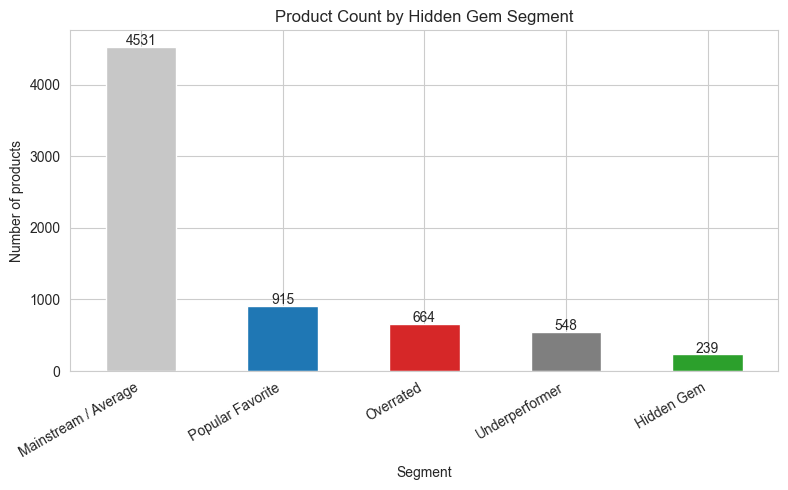

In [7]:
plt.figure(figsize=(8, 5))
segment_counts = eligible["gem_segment"].value_counts()
colors = {
    "Hidden Gem": "#2ca02c",
    "Overrated": "#d62728",
    "Popular Favorite": "#1f77b4",
    "Underperformer": "#7f7f7f",
    "Mainstream / Average": "#c7c7c7",
}
bar_colors = [colors[seg] for seg in segment_counts.index]

ax = segment_counts.plot(kind="bar", color=bar_colors)
plt.xlabel("Segment")
plt.ylabel("Number of products")
plt.title("Product Count by Hidden Gem Segment")
plt.xticks(rotation=30, ha="right")

for i, v in enumerate(segment_counts):
    ax.text(i, v + 20, str(v), ha="center")

plt.tight_layout()
plt.show()

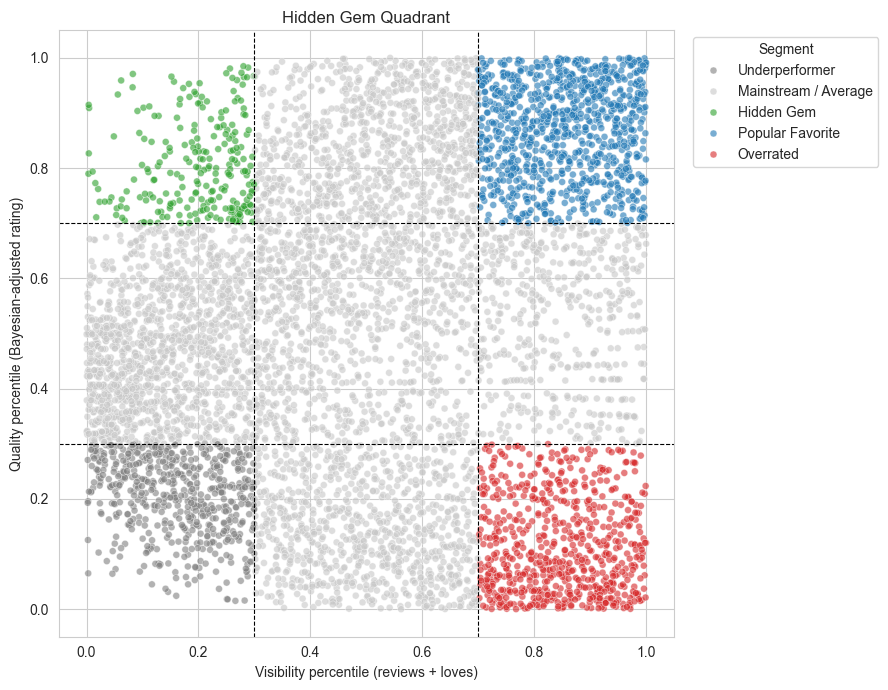

In [8]:
plt.figure(figsize=(9, 7))
palette = {
    "Hidden Gem": "#2ca02c",
    "Overrated": "#d62728",
    "Popular Favorite": "#1f77b4",
    "Underperformer": "#7f7f7f",
    "Mainstream / Average": "#c7c7c7",
}
sns.scatterplot(
    data=eligible, x="visibility_pct", y="quality_pct",
    hue="gem_segment", palette=palette, alpha=0.6, s=25
)
plt.axvline(0.30, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0.70, color="black", linestyle="--", linewidth=0.8)
plt.axhline(0.30, color="black", linestyle="--", linewidth=0.8)
plt.axhline(0.70, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Visibility percentile (reviews + loves)")
plt.ylabel("Quality percentile (Bayesian-adjusted rating)")
plt.title("Hidden Gem Quadrant")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

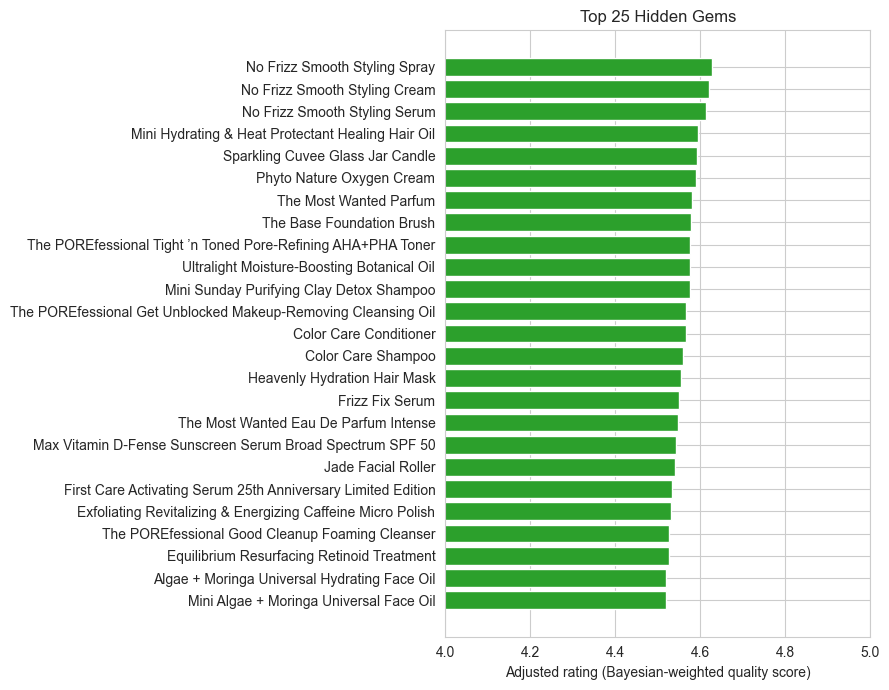

In [9]:
top_n = 25
top_gems = eligible[eligible["gem_segment"] == "Hidden Gem"].sort_values(
    "adjusted_rating", ascending=False
).head(top_n)

plt.figure(figsize=(9, 7))
plt.barh(top_gems["product_name"], top_gems["adjusted_rating"], color="#2ca02c")
plt.gca().invert_yaxis()  # highest-rated gem at the top
plt.xlabel("Adjusted rating (Bayesian-weighted quality score)")
plt.title(f"Top {top_n} Hidden Gems")
plt.xlim(4.0, 5.0)  # zoom in since adjusted_rating clusters near the top of the 1-5 scale
plt.tight_layout()
plt.show()

### Price-Based Outputs
- `qcut` splits products into 4 equal-size price groups: Budget, Mid, High, Premium.
- `best_value`: top 10 rated products overall, cheapest first if tied.
- `best_affordable`: top 10 rated products, but only within the Budget group.
- `premium_worth_it`: top 10 rated products, but only within Premium and only if quality is in the top 30%.

In [10]:
eligible["price_tier"] = pd.qcut(
    eligible["price_usd"], q=4, labels=["Budget", "Mid", "High", "Premium"]
)

best_value = eligible.sort_values(["adjusted_rating", "price_usd"], ascending=[False, True]).head(10)

best_affordable = eligible[eligible["price_tier"] == "Budget"].sort_values("adjusted_rating", ascending=False).head(10)

premium_worth_it = eligible[
    (eligible["price_tier"] == "Premium") & (eligible["quality_pct"] >= 0.70)
].sort_values("adjusted_rating", ascending=False).head(10)

cols = ["product_name", "brand_name", "price_usd", "rating", "adjusted_rating", "reviews", "primary_category"]

print("Best Value:")
display(best_value[cols])
print("\nBest Affordable:")
display(best_affordable[cols])
print("\nPremium Worth Their Price:")
display(premium_worth_it[cols])

Best Value:


,product_name,brand_name,price_usd,rating,adjusted_rating,reviews,primary_category
2921,Creamy Kohl Longwear Eye Pencil,HUDA BEAUTY,21.0,4.87,4.811288,1395.0,Makeup
5866,Facial Cotton,Shiseido,13.0,4.83,4.801499,2827.0,Skincare
1545,Yummy Skin Blurring Balm Powder Flushed - Matte Color for Cheek & Lip,Danessa Myricks Beauty,25.0,4.88,4.800861,1017.0,Makeup
5089,Major Beauty Headlines - Double-Take Crème & Powder Blush,PATRICK TA,36.0,4.85,4.795109,1452.0,Makeup
2377,Black Tea Anti-Aging Moisturizer with Retinol-Alternative BT Matrix,fresh,95.0,4.84,4.783622,1386.0,Skincare
222,Modern Renaissance Eye Shadow Palette,Anastasia Beverly Hills,45.0,4.79,4.781476,9133.0,Makeup
5354,Ralph's Club Eau de Parfum,Ralph Lauren,129.0,4.79,4.760867,2576.0,Fragrance
5114,Major Brow Defining Pencil,PATRICK TA,27.0,4.87,4.760515,685.0,Makeup
7263,L'Homme,Yves Saint Laurent,89.0,4.84,4.757888,909.0,Fragrance
5554,Solid Brush and Sponge Cleaner with Pad,SEPHORA COLLECTION,16.0,4.79,4.755916,2182.0,Makeup



Best Affordable:


,product_name,brand_name,price_usd,rating,adjusted_rating,reviews,primary_category
2921,Creamy Kohl Longwear Eye Pencil,HUDA BEAUTY,21.00,4.87,4.811288,1395.0,Makeup
5866,Facial Cotton,Shiseido,13.00,4.83,4.801499,2827.0,Skincare
1545,Yummy Skin Blurring Balm Powder Flushed - Matte Color for Cheek & Lip,Danessa Myricks Beauty,25.00,4.88,4.800861,1017.0,Makeup
5554,Solid Brush and Sponge Cleaner with Pad,SEPHORA COLLECTION,16.00,4.79,4.755916,2182.0,Makeup
5555,PRO Concealer Brush #57,SEPHORA COLLECTION,22.00,4.78,4.714141,1043.0,Makeup
231,Brush 12 Precision Brow Brush for Pomades & Gels,Anastasia Beverly Hills,18.00,4.74,4.697198,1551.0,Makeup
229,Ombre Effect Long Wearing Brow Powder Duo,Anastasia Beverly Hills,23.00,4.70,4.687214,5086.0,Makeup
620,Elixir Hair Oil Treatment with Castor Oil,BondiBoost,19.95,4.92,4.679484,266.0,Hair
5515,The Big Buffing Bronzer Brush,Saie,26.00,4.89,4.677597,300.0,Makeup
3944,Lilly Lashes Lite Faux Mink Lashes,Lilly Lashes,20.00,4.73,4.675959,1175.0,Makeup



Premium Worth Their Price:


,product_name,brand_name,price_usd,rating,adjusted_rating,reviews,primary_category
2377,Black Tea Anti-Aging Moisturizer with Retinol-Alternative BT Matrix,fresh,95.0,4.84,4.783622,1386.0,Skincare
5354,Ralph's Club Eau de Parfum,Ralph Lauren,129.0,4.79,4.760867,2576.0,Fragrance
7263,L'Homme,Yves Saint Laurent,89.0,4.84,4.757888,909.0,Fragrance
2381,Floral Recovery Overnight Mask with Squalane,fresh,69.0,4.80,4.736418,1128.0,Skincare
2373,Tea Elixir Niacinamide & Hyaluronic Acid Anti-Aging Serum,fresh,80.0,4.77,4.732008,1872.0,Skincare
309,Acqua di Giò Eau de Toilette Spray,Armani Beauty,110.0,4.74,4.701220,1726.0,Fragrance
7268,Libre Eau de Toilette,Yves Saint Laurent,139.0,4.79,4.697050,714.0,Fragrance
5097,Major Dimension II Rose Eyeshadow Palette,PATRICK TA,70.0,4.79,4.695831,703.0,Makeup
7290,Y Eau de Toilette,Yves Saint Laurent,120.0,4.74,4.686074,1203.0,Fragrance
1578,Daily Microfoliant Exfoliator,Dermalogica,65.0,4.70,4.685896,4598.0,Skincare


### Hidden Gems

In [11]:
print("Top 15 Hidden Gems:")
top_gems = eligible[eligible["gem_segment"] == "Hidden Gem"].sort_values("adjusted_rating", ascending=False).head(15)
display(top_gems[cols])

print("\nTop 15 Most Overrated:")
top_overrated = eligible[eligible["gem_segment"] == "Overrated"].sort_values("visibility_pct", ascending=False).head(15)
display(top_overrated[cols])

Top 15 Hidden Gems:


,product_name,brand_name,price_usd,rating,adjusted_rating,reviews,primary_category
3998,No Frizz Smooth Styling Spray,Living Proof,40.00,4.84,4.627605,268.0,Hair
3996,No Frizz Smooth Styling Cream,Living Proof,42.00,4.82,4.620749,281.0,Hair
4000,No Frizz Smooth Styling Serum,Living Proof,36.00,4.83,4.614573,256.0,Hair
7099,Mini Hydrating & Heat Protectant Healing Hair Oil,Virtue,26.00,4.73,4.594277,386.0,Hair
7151,Sparkling Cuvee Glass Jar Candle,VOLUSPA,34.00,4.96,4.592635,142.0,Fragrance
1606,Phyto Nature Oxygen Cream,Dermalogica,125.00,4.86,4.590099,192.0,Skincare
374,The Most Wanted Parfum,Azzaro,118.00,4.74,4.580601,317.0,Fragrance
5523,The Base Foundation Brush,Saie,26.00,4.88,4.578853,167.0,Makeup
473,The POREfessional Tight ’n Toned Pore-Refining AHA+PHA Toner,Benefit Cosmetics,34.00,4.65,4.576148,676.0,Skincare
6605,Ultralight Moisture-Boosting Botanical Oil,The Outset,44.00,4.84,4.575977,189.0,Skincare



Top 15 Most Overrated:


,product_name,brand_name,price_usd,rating,adjusted_rating,reviews,primary_category
2170,Pro Filt’r Soft Matte Longwear Liquid Foundation,Fenty Beauty by Rihanna,40.0,4.04,4.041347,16935.0,Makeup
3698,Tattoo Liner Vegan Waterproof Liquid Eyeliner,KVD Beauty,25.0,4.13,4.130502,21281.0,Makeup
6733,Better Than Sex Volumizing & Lengthening Mascara,Too Faced,28.0,3.74,3.743403,18610.0,Makeup
6735,Born This Way Natural Finish Longwear Liquid Foundation,Too Faced,45.0,4.04,4.041531,14882.0,Makeup
454,They're Real! Lengthening Mascara,Benefit Cosmetics,28.0,4.12,4.120762,15756.0,Makeup
3699,Lock-It Full-Coverage Long-Wear Matte Liquid Foundation,KVD Beauty,40.5,3.92,3.922692,14468.0,Makeup
221,Liquid Lipstick,Anastasia Beverly Hills,20.0,3.83,3.841786,4238.0,Makeup
1920,Protini Polypeptide Firming Refillable Moisturizer,Drunk Elephant,68.0,3.96,3.965477,6048.0,Skincare
453,The POREfessional Pore Minimizing Primer,Benefit Cosmetics,34.0,4.05,4.052758,7708.0,Makeup
2791,Vanish Seamless Finish Foundation Stick,Hourglass,49.0,4.01,4.014059,6534.0,Makeup


## Business Conclusions

**Business implications**

- **Hidden Gems** are strong candidates for increased marketing spend, homepage placement, or inclusion in "you might also like" modules — quality is already validated by the (small) customer base that found them.
- **Overrated** products deserve a closer look: is the visibility driven by advertising spend, influencer placement, or catalog positioning that isn't translating into satisfaction?
- **Premium Worth Their Price** products justify their price tag and can be leaned on in premium-focused campaigns without reputational risk.